In [1]:
!pip install pandas-datareader

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader as pdr

In [4]:
from datetime import datetime

### EDA

In [7]:
!pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 2.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 1.9 MB/s eta 0:00:01
   -------------------------------------- - 1.6/1.6 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.0 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15618 sha256=6cdc30a0c0ea24f75bf2ee85d71c896540dd582121baf763f2ba1107250b235a
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   -----------------------------

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [88]:
import yfinance as yf

df = yf.download('TSLA', start='2017-02-27', end='2022-02-24')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


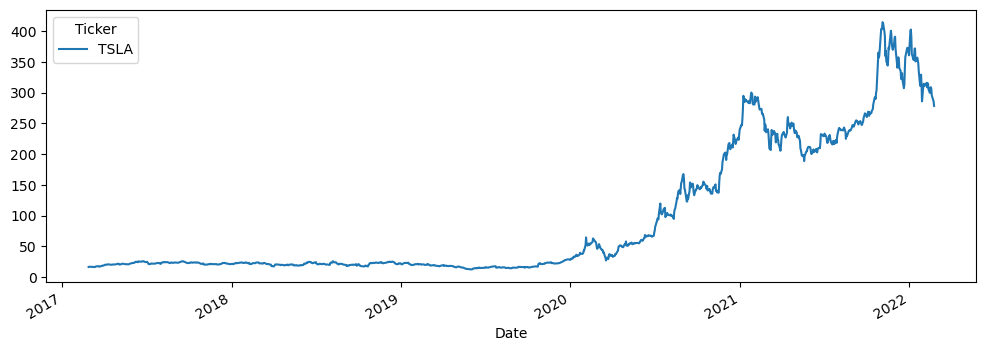

In [11]:
df['High'].plot(figsize=(12,4))
plt.show() 

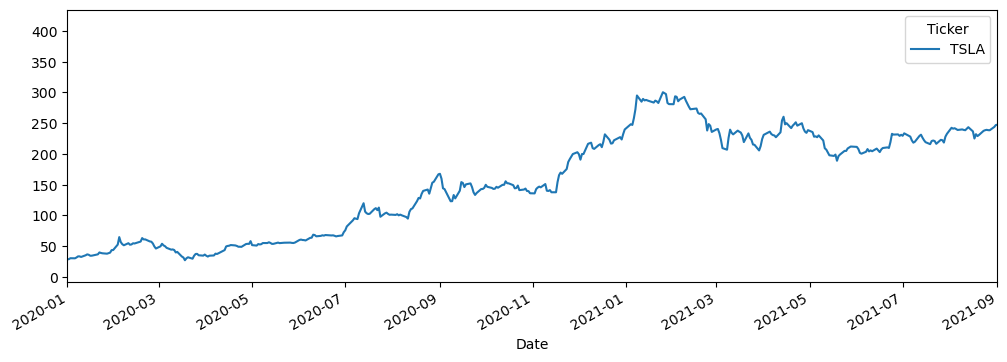

In [12]:
#xlimit and ylimit
df['High'].plot(xlim=['2020-01-01','2021-09-01'],figsize=(12,4))
plt.show()

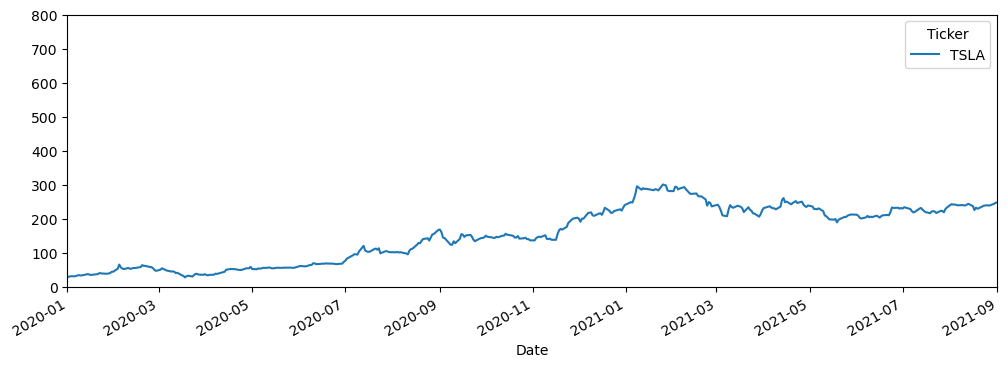

In [16]:
#xlimit and ylimit
df['High'].plot(xlim=['2020-01-01','2021-09-01'], ylim=[0,800] ,figsize=(12,4))
plt.show()

In [17]:
# can add color and linestyle

In [19]:
index = df.loc['2020-01-01':'2021-09-01'].index
share_open = df.loc['2020-01-01':'2021-09-01']['Open']
share_open

Ticker,TSLA
Date,
2020-01-02,28.299999
2020-01-03,29.366667
2020-01-06,29.364668
2020-01-07,30.760000
2020-01-08,31.580000
...,...
2021-08-26,236.103333
2021-08-27,235.000000
2021-08-30,238.240005


In [20]:
index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2021-08-19', '2021-08-20', '2021-08-23', '2021-08-24',
               '2021-08-25', '2021-08-26', '2021-08-27', '2021-08-30',
               '2021-08-31', '2021-09-01'],
              dtype='datetime64[ns]', name='Date', length=421, freq=None)

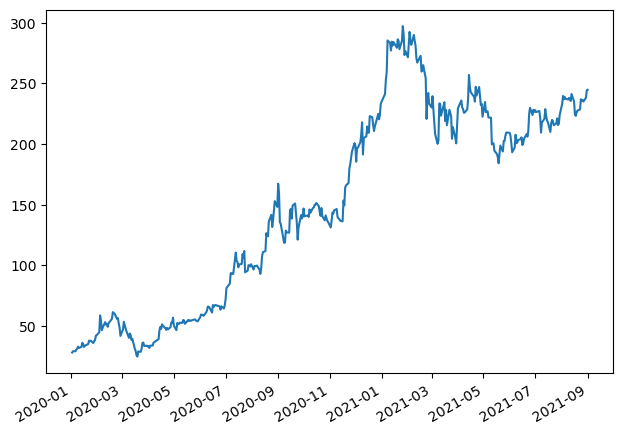

In [24]:
fig, ax = plt.subplots()
plt.tight_layout()
fig.autofmt_xdate()
ax.plot(index, share_open)
plt.show()

In [26]:
new = df.reset_index()

In [27]:
new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1258 non-null   datetime64[ns]
 1   (Close, TSLA)   1258 non-null   float64       
 2   (High, TSLA)    1258 non-null   float64       
 3   (Low, TSLA)     1258 non-null   float64       
 4   (Open, TSLA)    1258 non-null   float64       
 5   (Volume, TSLA)  1258 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


In [28]:
#date already in datetime otherwise convert
df = new.set_index('Date',drop=True)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


In [30]:
#datetime(y,m,d) creates a datetime obj
d = datetime.now()

In [32]:
print(d.day, d.month, d.year, d.weekday())

31 1 2026 5


### Time Resampling

In [34]:
df.resample(rule='YE').min()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-12-31,16.246000,16.433332,16.134001,16.279333,43791000
2018-12-31,16.704000,17.355333,16.306000,16.851999,46210500
2019-12-31,11.931333,12.445333,11.799333,12.073333,36984000
2020-12-31,24.081333,26.990667,23.367332,24.980000,52073100
2021-12-31,187.666672,188.736664,179.830002,184.183334,29401800
2022-12-31,254.679993,278.433319,253.520004,276.809998,50729100


In [35]:
df.resample(rule='YE').max()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-12-31,25.666668,25.974001,25.290001,25.779333,296871000
2018-12-31,25.304667,25.830667,24.474667,25.000000,504745500
2019-12-31,28.729334,29.020666,28.423332,29.000000,450091500
2020-12-31,235.223328,239.573334,230.373337,233.330002,914082000
2021-12-31,409.970001,414.496674,405.666656,411.470001,268189500
2022-12-31,399.926666,402.666656,378.679993,396.516663,151565700


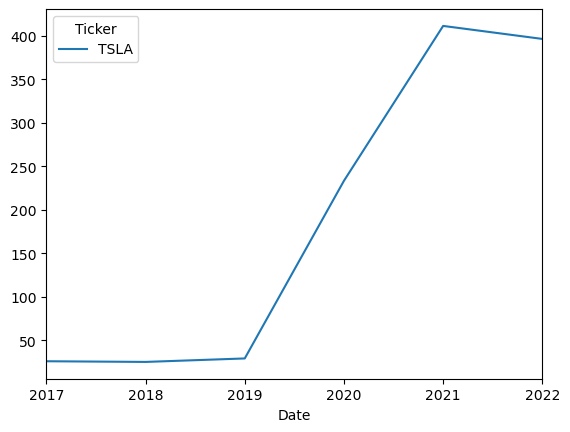

In [37]:
df.resample(rule='YE').max()['Open'].plot()
plt.show()

In [46]:
df.resample(rule='QS').min()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-01-01,16.246000,16.433332,16.134001,16.279333,43791000
2017-04-01,19.666668,19.933332,18.972000,19.126667,45535500
2017-07-01,20.588667,21.133333,20.208668,20.860001,45742500
2017-10-01,19.950666,20.297333,19.508667,19.966667,48661500
2018-01-01,17.185333,17.912001,16.547333,17.099333,48294000
2018-04-01,16.832001,17.355333,16.306000,16.851999,58126500
2018-07-01,17.549334,17.889999,16.816668,17.340000,54039000
2018-10-01,16.704000,17.457333,16.518000,17.016666,46210500


<Axes: xlabel='Date'>

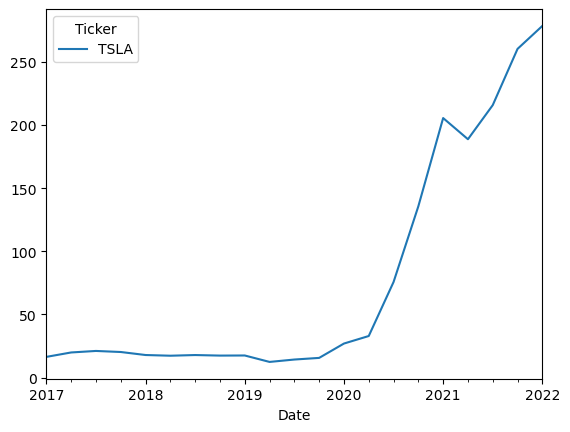

In [47]:
df.resample(rule='QS').min()['High'].plot()

In [52]:
#business year end
df.resample(rule='BYE').max()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-12-29,25.666668,25.974001,25.290001,25.779333,296871000
2018-12-31,25.304667,25.830667,24.474667,25.000000,504745500
2019-12-31,28.729334,29.020666,28.423332,29.000000,450091500
2020-12-31,235.223328,239.573334,230.373337,233.330002,914082000
2021-12-31,409.970001,414.496674,405.666656,411.470001,268189500
2022-12-30,399.926666,402.666656,378.679993,396.516663,151565700


In [51]:
#business quarter start
df.resample(rule='BQS').min()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-01-02,16.246000,16.433332,16.134001,16.279333,43791000
2017-04-03,19.666668,19.933332,18.972000,19.126667,45535500
2017-07-03,20.588667,21.133333,20.208668,20.860001,45742500
2017-10-02,19.950666,20.297333,19.508667,19.966667,48661500
2018-01-01,17.185333,17.912001,16.547333,17.099333,48294000
2018-04-02,16.832001,17.355333,16.306000,16.851999,58126500
2018-07-02,17.549334,17.889999,16.816668,17.340000,54039000
2018-10-01,16.704000,17.457333,16.518000,17.016666,46210500


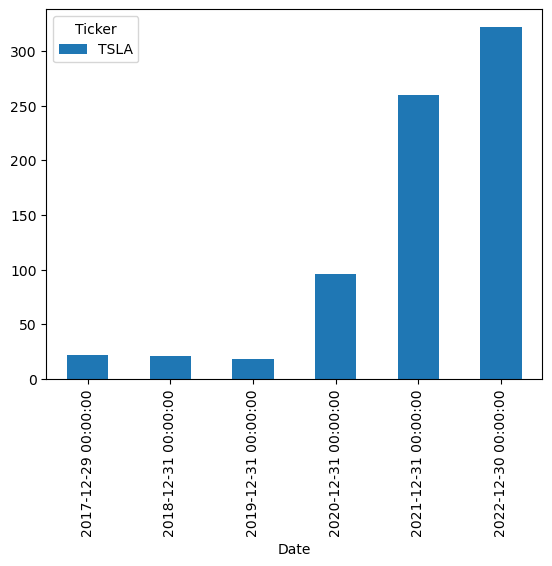

In [54]:
df['Open'].resample(rule='BYE').mean().plot(kind='bar')
plt.show()

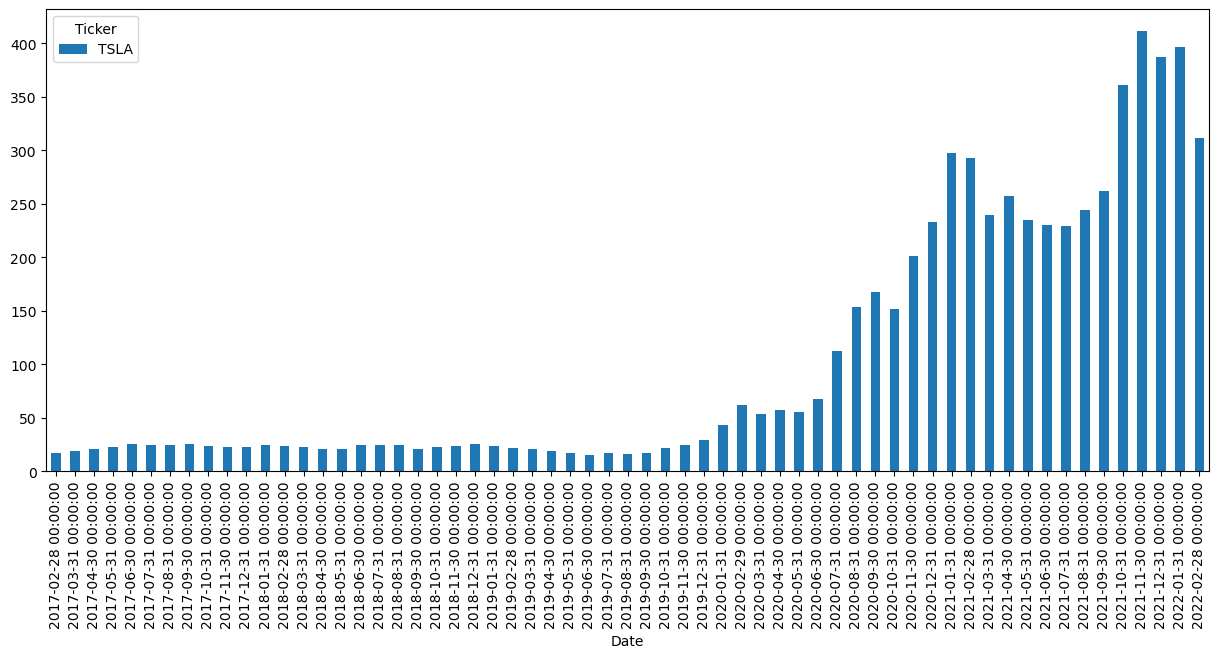

In [59]:
df['Open'].resample(rule='ME').max().plot(kind='bar', figsize=(15,6))
plt.show()

In [63]:
df['High'].rolling(window=3).mean().head(6)

Ticker,TSLA
Date,
2017-02-27,NaN
2017-02-28,NaN
2017-03-01,16.760222
2017-03-02,16.869555
2017-03-03,16.889555
2017-03-06,16.819555


In [64]:
df['High'].head()

Ticker,TSLA
Date,
2017-02-27,16.557333
2017-02-28,16.733334
2017-03-01,16.990000
2017-03-02,16.885332
2017-03-03,16.793333


### Rolling mean

In [89]:
df['Open:30 days rolling'] = df['Open'].rolling(30).mean()
df.head()

Price,Close,High,Low,Open,Volume,Open:30 days rolling
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000,NaN
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500,NaN
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500,NaN
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000,NaN
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000,NaN


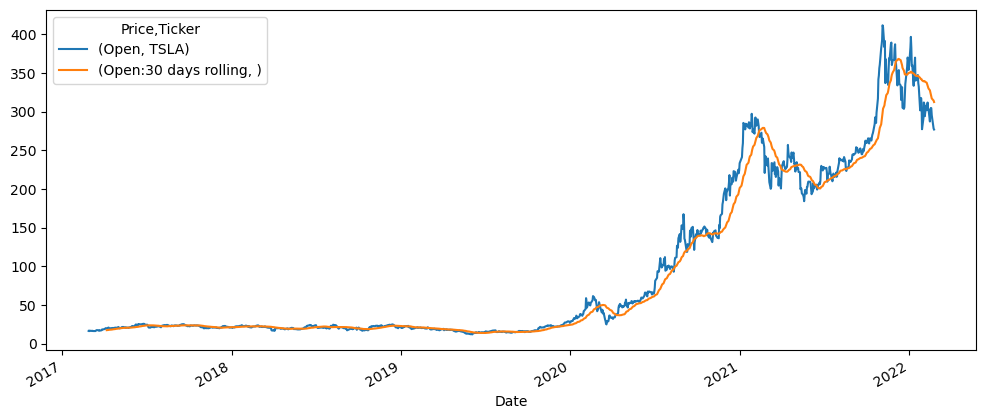

In [90]:
df[['Open','Open:30 days rolling']]. plot(figsize=(12,5))
plt.show()

1. read microsoft data
2. get max price of share from 2017-2022
3. which is date of the highest price of stock
4. date of lowest price of stock

In [103]:
df = yf.download('TSLA', start='2017-02-27', end='2022-02-25')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-02-27,16.415333,16.557333,16.134001,16.544666,171912000
2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500
2017-03-01,16.667999,16.990000,16.607332,16.945333,72142500
2017-03-02,16.698668,16.885332,16.551332,16.647333,50277000
2017-03-03,16.771334,16.793333,16.600000,16.716000,43791000


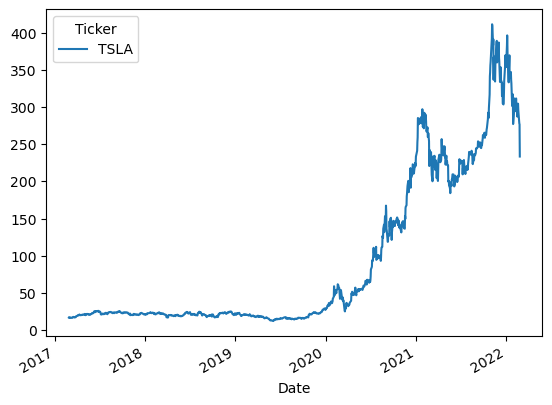

In [104]:
df['Open'].plot()
plt.show()

1. SMA

In [105]:
df['Open:10 days rolling'] = df['Open'].rolling(window=10, min_periods=1).mean()
df['Open:10 days rolling']

Date
2017-02-27     16.544666
2017-02-28     16.412000
2017-03-01     16.589778
2017-03-02     16.604167
2017-03-03     16.626533
                 ...    
2022-02-17    302.280664
2022-02-18    301.906665
2022-02-22    298.917999
2022-02-23    296.414667
2022-02-24    288.594334
Name: Open:10 days rolling, Length: 1259, dtype: float64

<Axes: xlabel='Date'>

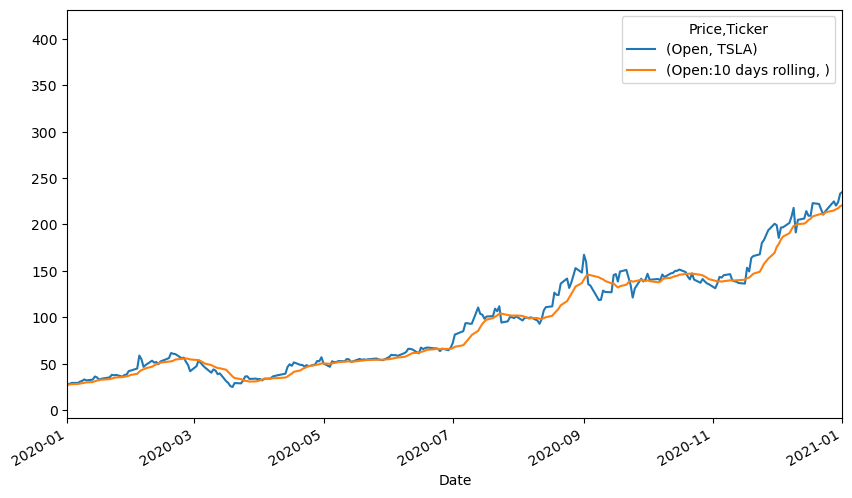

In [106]:
df[['Open','Open:10 days rolling']].plot(xlim=['2020-01-01','2021-01-01'], figsize=(10,6))

In [107]:
df['Open:30 days rolling'] = df['Open'].rolling(window=30, min_periods=1).mean()
df['Open:50 days rolling'] = df['Open'].rolling(window=50, min_periods=1).mean()

<Axes: xlabel='Date'>

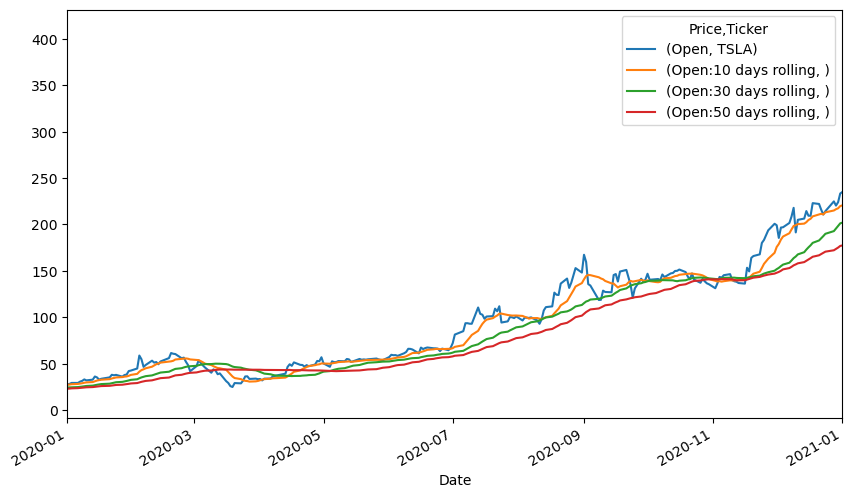

In [108]:
df[['Open','Open:10 days rolling','Open:30 days rolling','Open:50 days rolling']].plot(xlim=['2020-01-01','2021-01-01'], figsize=(10,6))

2. CMA

<Axes: xlabel='Date'>

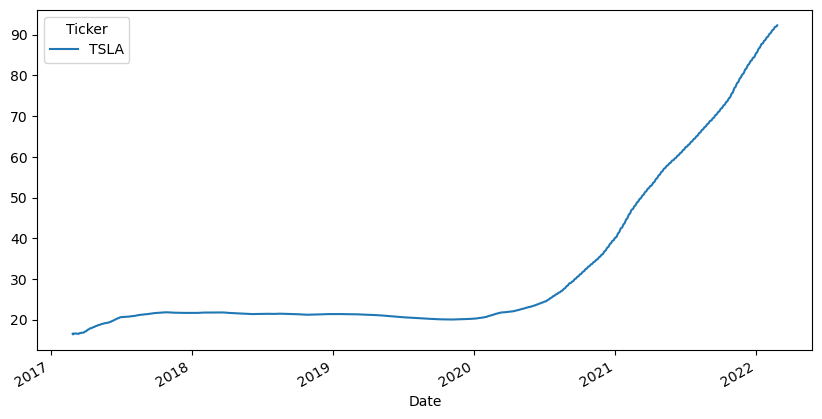

In [109]:
df['Open'].expanding().mean().plot(figsize=(10,5))

3. EMA

In [110]:
#smoothing factor
df['ema_0.1'] = df['Open'].ewm(alpha=0.1, adjust=False).mean()

<Axes: xlabel='Date'>

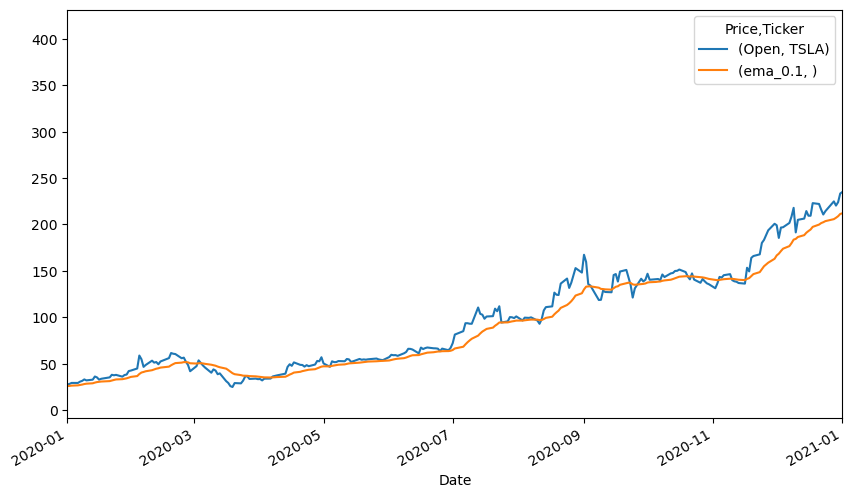

In [111]:
df[['Open','ema_0.1']].plot(xlim=['2020-01-01','2021-01-01'], figsize=(10,6))

In [112]:
df['ema_0.3'] = df['Open'].ewm(alpha=0.3, adjust=False).mean()

<Axes: xlabel='Date'>

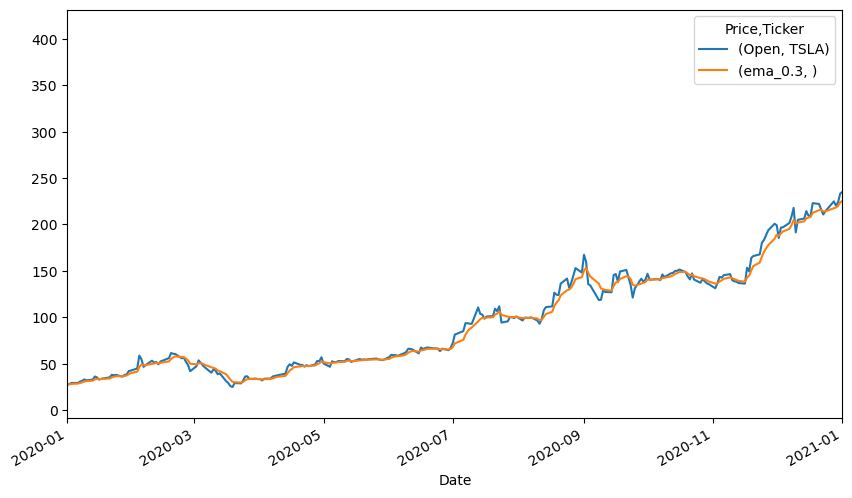

In [113]:
df[['Open','ema_0.3']].plot(xlim=['2020-01-01','2021-01-01'], figsize=(10,6))

<Axes: xlabel='Date'>

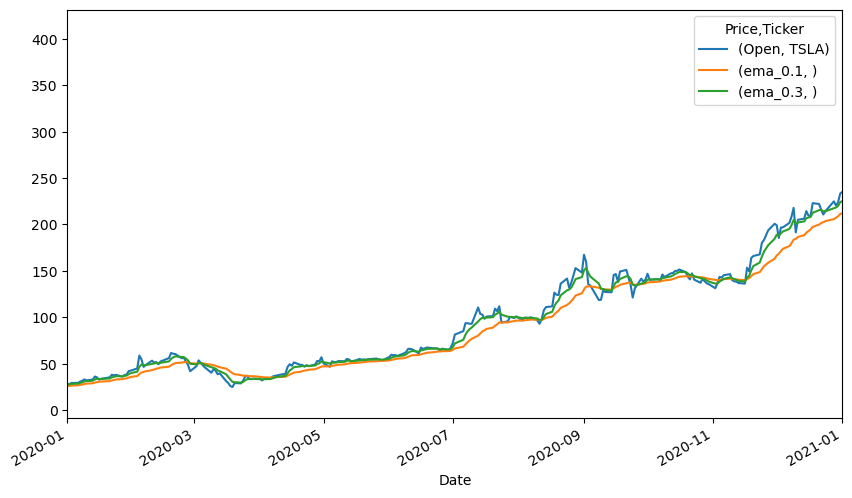

In [114]:
df[['Open','ema_0.1','ema_0.3']].plot(xlim=['2020-01-01','2021-01-01'], figsize=(10,6))

<Axes: xlabel='Date'>

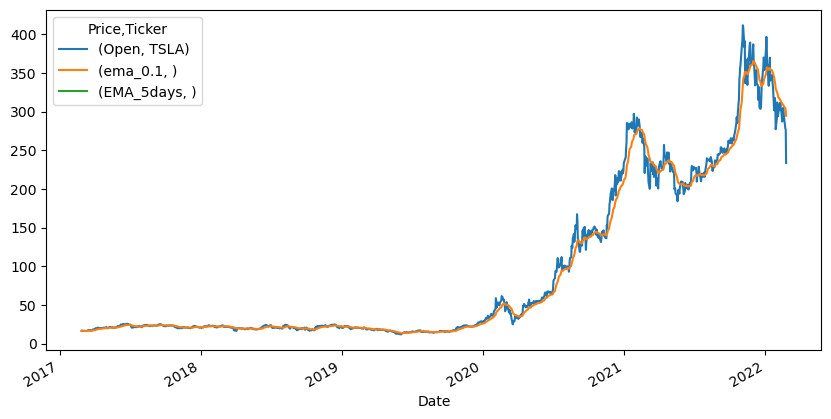

In [117]:
df['EMA_5days'] = df['Open'].ewm(span=5).mean()
df[['Open','ema_0.1','EMA_5days']].plot(figsize=(10,5))

### ARIMA

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sms
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv("C:/Users/hp/Downloads/Datasets/airline_passengers.csv")
df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [88]:
df.isnull().sum()

Month                      0
Thousands of Passengers    1
dtype: int64

In [89]:
df.dropna(axis=0, inplace=True)

In [90]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    144 non-null    object 
 1   Thousands of Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.4+ KB


In [91]:
df['Month'] = pd.to_datetime(df['Month'])

In [92]:
df.head()

,Month,Thousands of Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [93]:
df.set_index('Month',inplace=True)

In [94]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


<Axes: xlabel='Month'>

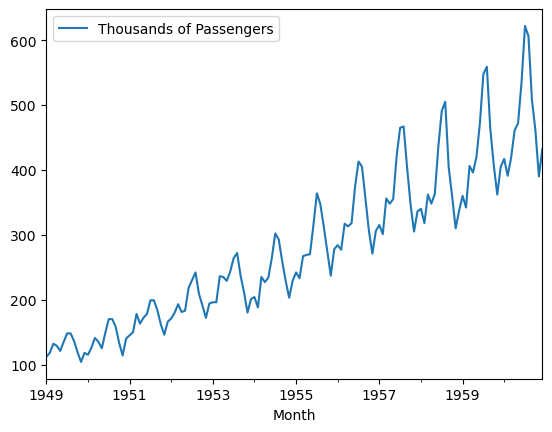

In [95]:
df.plot()

In [96]:
from statsmodels.tsa.stattools import adfuller

In [99]:
def adf_test(data):
    res = adfuller(data)
    print('ADF static: {}'.format(res[0]))
    print('p-value: {}'.format(res[1]))
    if res[1] <= 0.05:
        print('Reject null hypothesis -> Stationary')
    else:
        print('Not stationary')

In [100]:
adf_test(df['Thousands of Passengers'])

ADF static: 0.8153688792060482
p-value: 0.991880243437641
Not stationary


In [101]:
df['first difference'] = df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(1)

In [102]:
df.head()

,Thousands of Passengers,first difference
Month,,
1949-01-01,112.0,NaN
1949-02-01,118.0,6.0
1949-03-01,132.0,14.0
1949-04-01,129.0,-3.0
1949-05-01,121.0,-8.0


In [103]:
adf_test(df['first difference'].dropna())

ADF static: -2.8292668241699994
p-value: 0.0542132902838255
Not stationary


In [104]:
df['second difference'] = df['first difference'] - df['first difference'].shift(1)

In [105]:
df.head()

,Thousands of Passengers,first difference,second difference
Month,,,
1949-01-01,112.0,NaN,NaN
1949-02-01,118.0,6.0,NaN
1949-03-01,132.0,14.0,8.0
1949-04-01,129.0,-3.0,-17.0
1949-05-01,121.0,-8.0,-5.0


In [106]:
adf_test(df['second difference'].dropna())

ADF static: -16.384231542468505
p-value: 2.7328918500142407e-29
Reject null hypothesis -> Stationary


In [107]:
### seasonal
df['12 month'] = df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(12)

In [108]:
adf_test(df['12 month'].dropna())

ADF static: -3.383020726492481
p-value: 0.011551493085514952
Reject null hypothesis -> Stationary


In [109]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

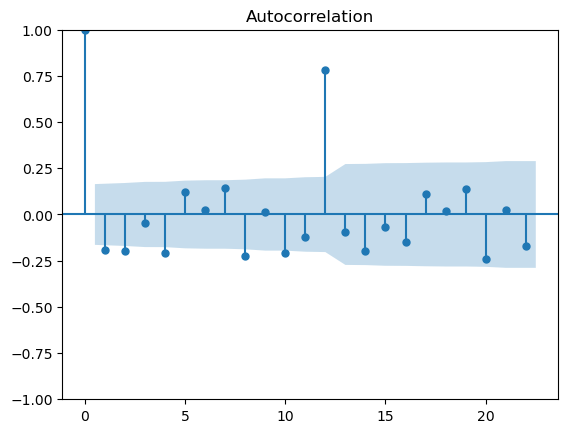

In [110]:
acf = plot_acf(df['second difference'].dropna())

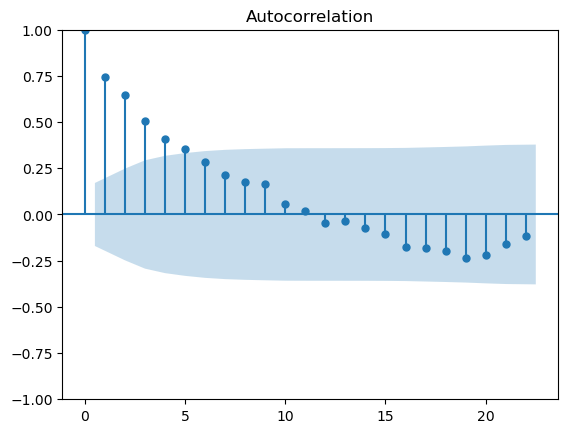

In [111]:
# some seasonality exists in above plot, normal for a few points then increases at one certain point
acf = plot_acf(df['12 month'].dropna())

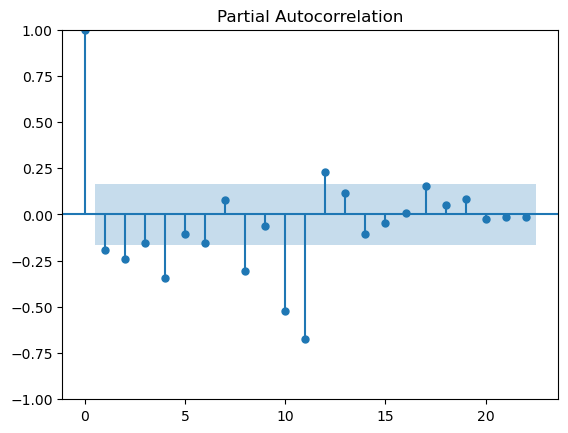

In [112]:
pacf = plot_pacf(df['second difference'].dropna())

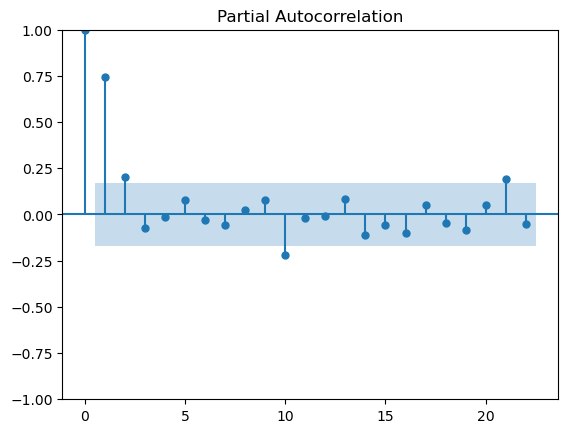

In [113]:
pacf12 = plot_pacf(df['12 month'].dropna())

In [114]:
df.head()

,Thousands of Passengers,first difference,second difference,12 month
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN


In [125]:
from datetime import datetime, timedelta
train_end = datetime(1955,12,1)
test_end = datetime(1960,12,1)

In [126]:
train_data = df[:train_end]
test_data = df[train_end+timedelta(days=1):test_end] # timedelta: Sets the start date of the test set to the day immediately after the training set ends.

In [127]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]

In [130]:
from statsmodels.tsa.arima.model import ARIMA

In [132]:
model = ARIMA(train_data['Thousands of Passengers'], order=(10,2,0))

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [133]:
model_fit = model.fit()

In [134]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                     ARIMA(10, 2, 0)   Log Likelihood                -357.239
Date:                     Tue, 03 Feb 2026   AIC                            736.477
Time:                             12:29:59   BIC                            762.951
Sample:                         01-01-1949   HQIC                           747.106
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5166      0.121     -4.262      0.000      -0.754      -0.279
ar.L2         -0.7204      0.121     -5.940      0.000      -0.958      -0.483
ar.L3         -0.4857      0.125     -3.876      0.000      -0.731      -0.240
ar.L4         -0.7505      0.129     -5.819      0.000      -1.003      -0.498
ar.L5         -0.5062      0.169     -2.991      0.003      -0.838      -0.175
ar.L6         -0.5200      0.141     -3.683      0.000      -0.797      -0.243
ar.L7         -0.3051      0.143     -2.127      0.033      -0.586      -0.024
ar.L8         -0.5939      0.155     -3.833      0.000      -0.898      -0.290
ar.L9         -0.2963      0.132     -2.241      0.025      -0.555      -0.037
ar.L10        -0.4825      0.110     -4.376      0.000      -0.699      -0.266
sigma2       336.0939     66.064      5.087      0.000     206.612     465.576
===================================================================================
Ljung-Box (L1) (Q):                  10.86   Jarque-Bera (JB):                 1.24
Prob(Q):                              0.00   Prob(JB):                         0.54
Heteroskedasticity (H):               2.85   Skew:                             0.24
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [135]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [140]:
pred = model_fit.predict(start=pred_start_date, end=pred_end_date)
residuals = test_data['Thousands of Passengers'] - pred

In [142]:
residuals.head()

Month
1956-01-01   -16.183614
1956-02-01   -32.478357
1956-03-01     0.556986
1956-04-01     5.172458
1956-05-01    -0.544232
dtype: float64

<Axes: ylabel='Density'>

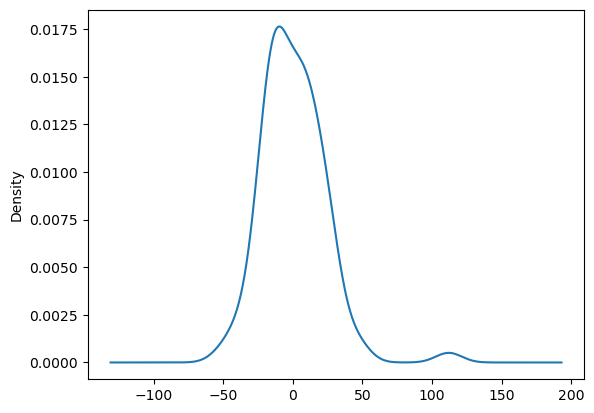

In [143]:
model_fit.resid.plot(kind='kde')

In [144]:
test_data['Predicted_ARIMA'] = pred

C:\Users\hp\AppData\Local\Temp\ipykernel_12344\284031954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA'] = pred


<Axes: xlabel='Month'>

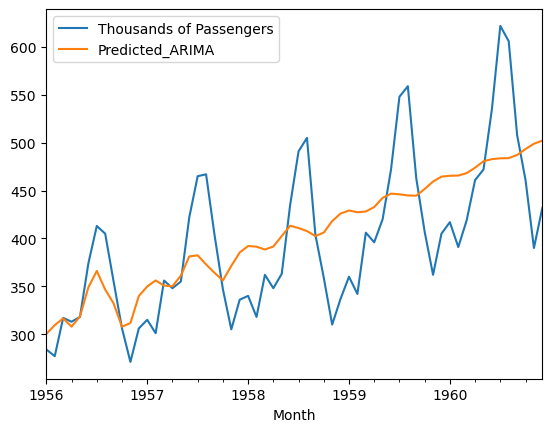

In [145]:
test_data[['Thousands of Passengers','Predicted_ARIMA']].plot()

In [147]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [148]:
models = SARIMAX(train_data['Thousands of Passengers'], order=(3,0,5), seasonal_order=(0,1,0,12))

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [149]:
models_fit = models.fit()

F:\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [150]:
models_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(3, 0, 5)x(0, 1, [], 12)   Log Likelihood                -265.240
Date:                             Tue, 03 Feb 2026   AIC                            548.479
Time:                                     13:01:18   BIC                            568.969
Sample:                                 01-01-1949   HQIC                           556.636
                                      - 12-01-1955                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5919      0.948      0.624      0.533      -1.267       2.451
ar.L2          0.8320      0.231      3.594      0.000       0.378       1.286
ar.L3         -0.4469      0.903     -0.495      0.621      -2.217       1.323
ma.L1          0.1904      1.196      0.159      0.874      -2.154       2.535
ma.L2         -0.5297      1.292     -0.410      0.682      -3.061       2.002
ma.L3         -0.1004      0.393     -0.255      0.799      -0.871       0.671
ma.L4         -0.1287      0.351     -0.367      0.714      -0.817       0.559
ma.L5          0.2454      0.366      0.670      0.503      -0.472       0.963
sigma2        87.7556     84.773      1.035      0.301     -78.397     253.908
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.67
Prob(Q):                              0.88   Prob(JB):                         0.26
Heteroskedasticity (H):               2.04   Skew:                             0.46
Prob(H) (two-sided):                  0.09   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [152]:
preds = models_fit.predict(start=pred_start_date, end=pred_end_date)
res = test_data['Thousands of Passengers'] - preds

In [153]:
res.head()

Month
1956-01-01   -2.186668
1956-02-01   -4.293797
1956-03-01    7.064178
1956-04-01    2.284629
1956-05-01    6.611277
dtype: float64

<Axes: ylabel='Density'>

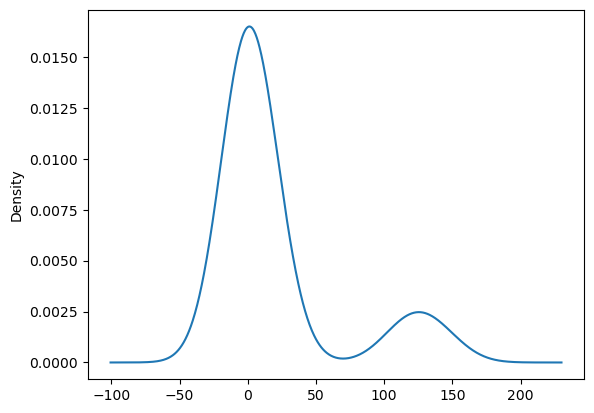

In [154]:
models_fit.resid.plot(kind='kde')

In [155]:
test_data['Predicted_SARIMAX'] = preds

C:\Users\hp\AppData\Local\Temp\ipykernel_12344\1222799739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_SARIMAX'] = preds


<Axes: xlabel='Month'>

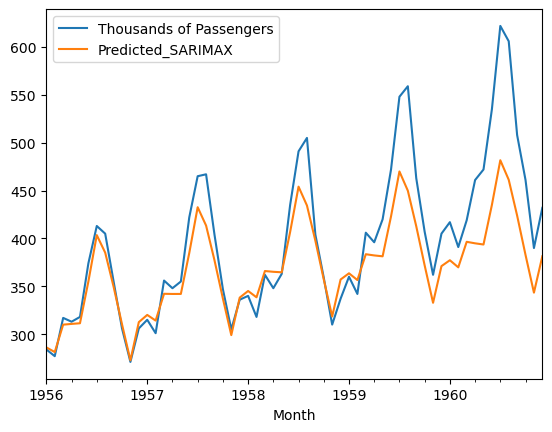

In [156]:
test_data[['Thousands of Passengers','Predicted_SARIMAX']].plot()

<Axes: xlabel='Month'>

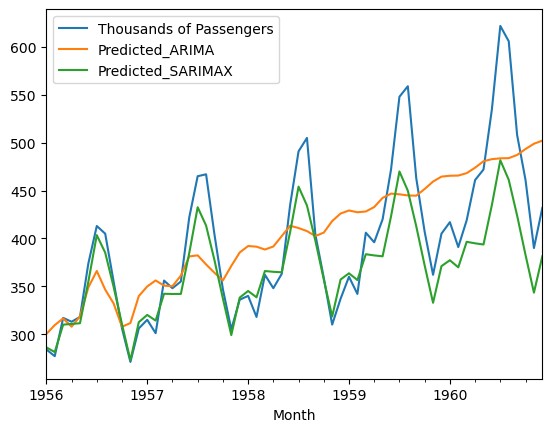

In [157]:
test_data[['Thousands of Passengers','Predicted_ARIMA','Predicted_SARIMAX']].plot()

In [158]:
!pip install prophet

  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 2.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/12.1 MB 3.3 MB/s eta 0:00:04
   --------- ------------------------------ 2.9/12.1 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.1 MB 3.9 MB/s eta 0:00:03
   ---------------- ----------------------- 5.0/12.1 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.1 MB 4.5 MB/s eta 0:00:02
   ------------------------- -------------- 7.9/12.1 MB 4.8 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.1 MB 5.1 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.1 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 5.5 MB/s eta 0:00:00
   ---------

In [159]:
import prophet

In [160]:
df = pd.read_csv("C:/Users/hp/Downloads/Datasets/airline_passengers.csv")
df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [161]:
df.dropna(axis=0, inplace=True)

<Axes: >

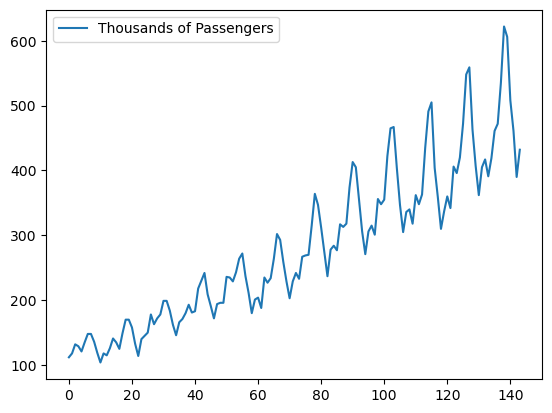

In [162]:
df.plot()

In [163]:
df.columns = ['ds','y']
df.head()

,ds,y
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [167]:
df['ds'] = pd.to_datetime(df['ds'])

In [169]:
from prophet import Prophet

In [171]:
model = Prophet()

In [172]:
model.fit(df)

15:34:18 - cmdstanpy - INFO - Chain [1] start processing
15:34:19 - cmdstanpy - INFO - Chain [1] done processing


In [173]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [175]:
future = model.make_future_dataframe(periods=365)
future.head()

,ds
0,1949-01-01
1,1949-02-01
2,1949-03-01
3,1949-04-01
4,1949-05-01


In [177]:
pred = model.predict(future)
pred.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,106.662351,56.327872,111.529131,106.662351,106.662351,-21.848235,-21.848235,-21.848235,-21.848235,-21.848235,-21.848235,0.0,0.0,0.0,84.814116
1,1949-02-01,108.835378,48.278728,106.126423,108.835378,108.835378,-30.607610,-30.607610,-30.607610,-30.607610,-30.607610,-30.607610,0.0,0.0,0.0,78.227768
2,1949-03-01,110.798112,81.517908,139.235273,110.798112,110.798112,-0.455867,-0.455867,-0.455867,-0.455867,-0.455867,-0.455867,0.0,0.0,0.0,110.342245
3,1949-04-01,112.971139,78.848888,136.751789,112.971139,112.971139,-5.160420,-5.160420,-5.160420,-5.160420,-5.160420,-5.160420,0.0,0.0,0.0,107.810719
4,1949-05-01,115.074068,82.238875,141.652216,115.074068,115.074068,-3.807959,-3.807959,-3.807959,-3.807959,-3.807959,-3.807959,0.0,0.0,0.0,111.266109


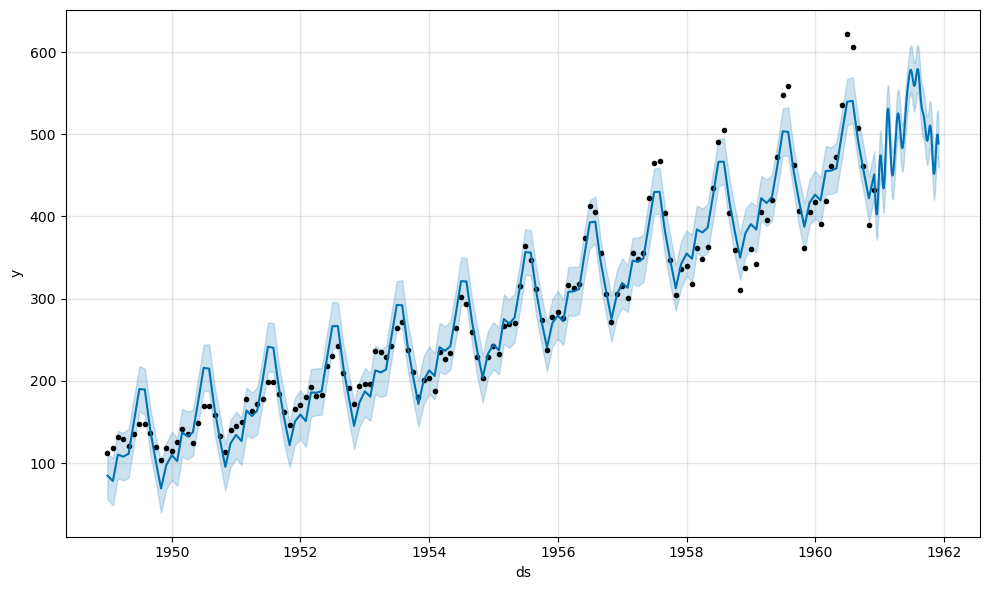

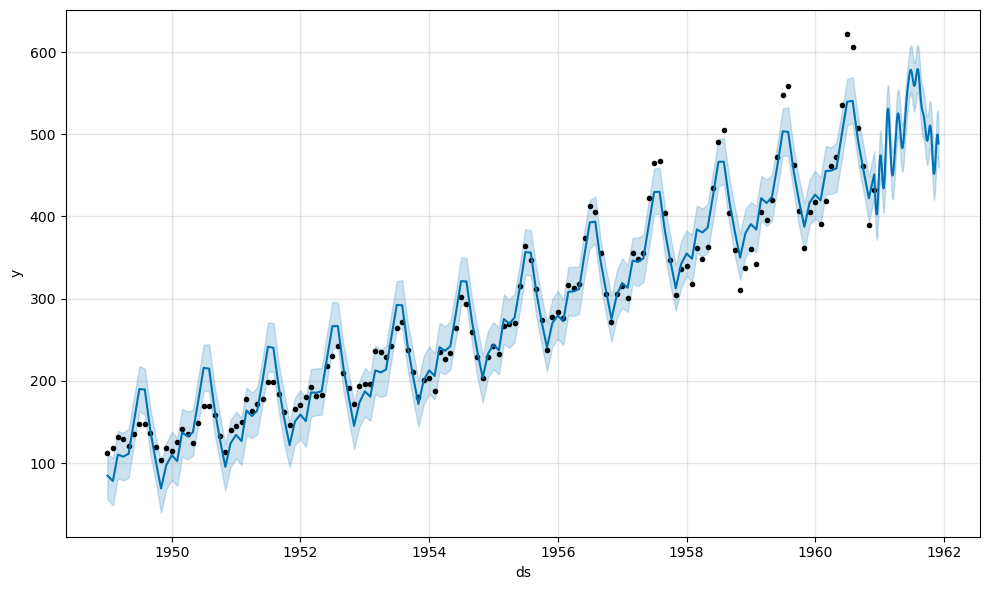

In [179]:
model.plot(pred)

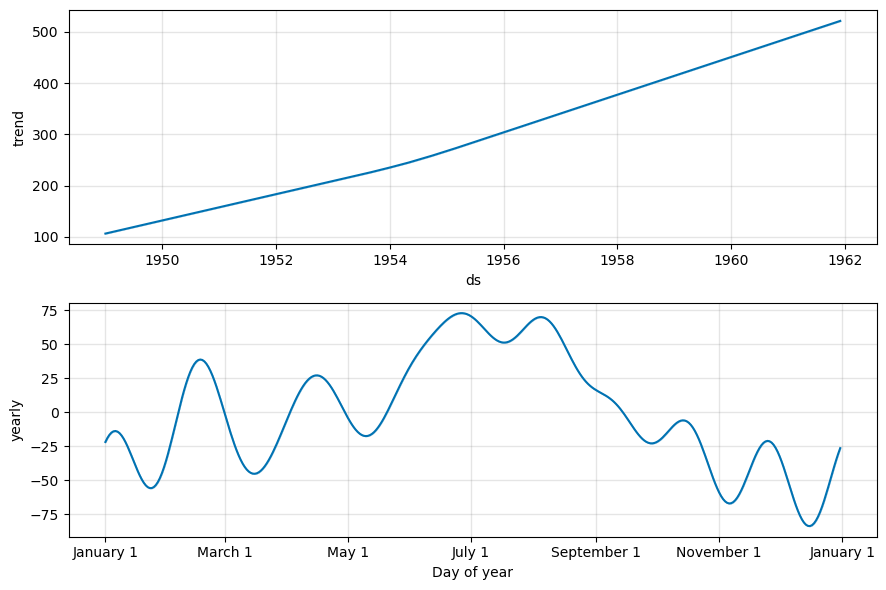

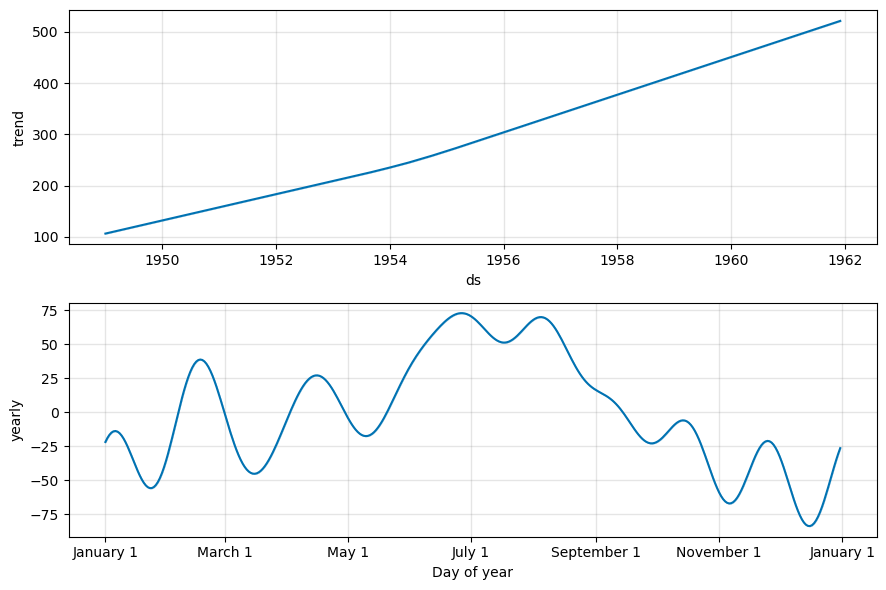

In [180]:
model.plot_components(pred)

In [182]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
df_cv.head()

  0%|          | 0/19 [00:00<?, ?it/s]

15:44:18 - cmdstanpy - INFO - Chain [1] start processing
15:44:33 - cmdstanpy - INFO - Chain [1] done processing
15:44:34 - cmdstanpy - INFO - Chain [1] start processing
15:44:34 - cmdstanpy - INFO - Chain [1] done processing
15:44:34 - cmdstanpy - INFO - Chain [1] start processing
15:44:35 - cmdstanpy - INFO - Chain [1] done processing
15:44:35 - cmdstanpy - INFO - Chain [1] start processing
15:44:35 - cmdstanpy - INFO - Chain [1] done processing
15:44:36 - cmdstanpy - INFO - Chain [1] start processing
15:44:36 - cmdstanpy - INFO - Chain [1] done processing
15:44:36 - cmdstanpy - INFO - Chain [1] start processing
15:44:37 - cmdstanpy - INFO - Chain [1] done processing
15:44:37 - cmdstanpy - INFO - Chain [1] start processing
15:44:37 - cmdstanpy - INFO - Chain [1] done processing
15:44:37 - cmdstanpy - INFO - Chain [1] start processing
15:44:38 - cmdstanpy - INFO - Chain [1] done processing
15:44:38 - cmdstanpy - INFO - Chain [1] start processing
15:44:38 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,157.204923,156.952084,157.390356,150.0,1951-01-18
1,1951-03-01,169.726451,168.912121,170.370566,178.0,1951-01-18
2,1951-04-01,157.272723,155.837254,158.517424,163.0,1951-01-18
3,1951-05-01,143.304541,140.942099,145.238986,172.0,1951-01-18
4,1951-06-01,178.017915,174.505686,180.878832,178.0,1951-01-18


In [183]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1087.585383,32.978559,25.828263,0.078205,0.073741,0.079259,0.227273
1,42 days,1014.335537,31.848635,25.247414,0.076910,0.073741,0.077630,0.181818
2,46 days,909.314434,30.154841,24.670964,0.078810,0.079314,0.078584,0.136364
3,47 days,1044.684948,32.321586,26.845558,0.081985,0.085520,0.082145,0.136364
4,48 days,1034.254324,32.159825,26.300179,0.080102,0.085520,0.080328,0.181818


F:\Anaconda3\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
F:\Anaconda3\Lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


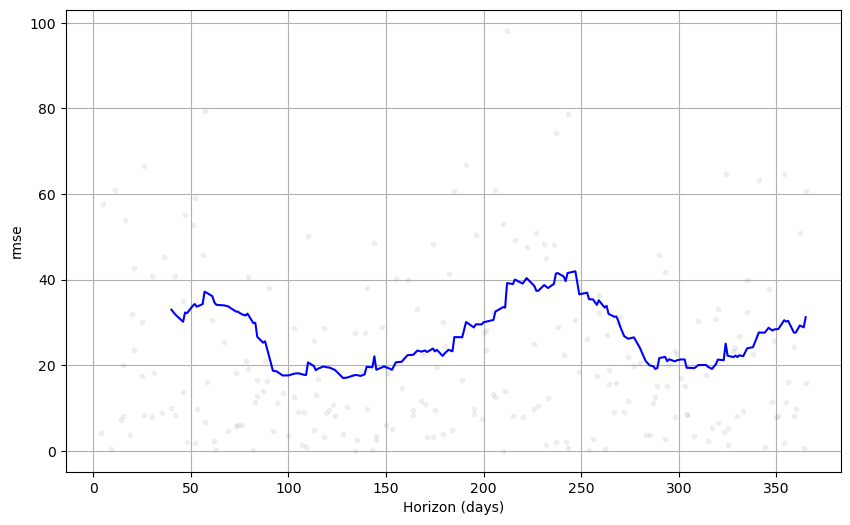

In [185]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

### non-useful

In [376]:
df = pd.read_csv("C:/Users/hp/Downloads/Walmart Sales Regression/Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [377]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [378]:
df['Date'].sort_values(ascending=False)

6434   2012-10-26
3145   2012-10-26
5433   2012-10-26
4289   2012-10-26
1000   2012-10-26
          ...    
1859   2010-02-05
4576   2010-02-05
2002   2010-02-05
4433   2010-02-05
0      2010-02-05
Name: Date, Length: 6435, dtype: datetime64[ns]

In [379]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [381]:
df.set_index('Date', inplace=True)

In [382]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106


In [383]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()
week_sales = df.groupby('Date')['Weekly_Sales'].sum()

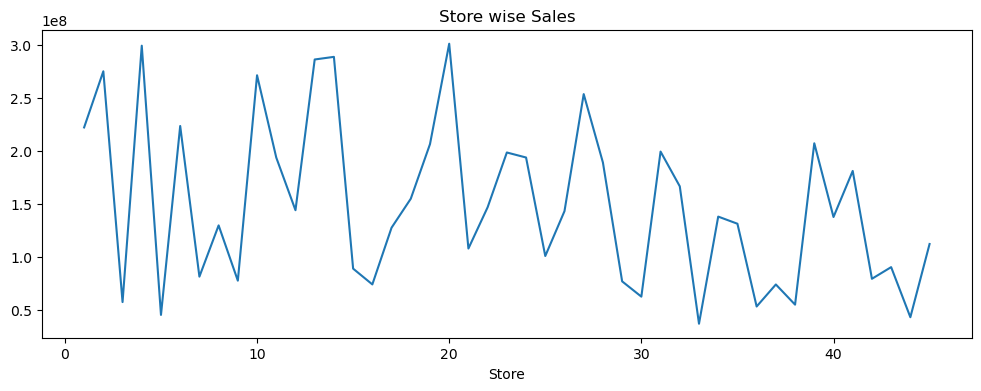

In [384]:
store_sales.plot(figsize=(12,4))
plt.title('Store wise Sales')
plt.show()

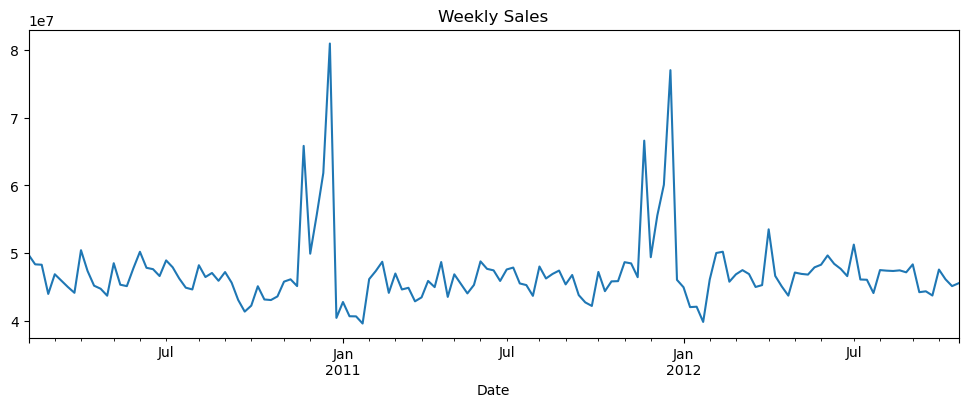

In [385]:
week_sales.plot(figsize=(12,4))
plt.title('Weekly Sales')
plt.show()

In [386]:
from statsmodels.tsa.stattools import adfuller

In [387]:
def adf_test(data):
    res = adfuller(data)
    print('ADF static: {}'.format(res[0]))
    print('p-value: {}'.format(res[1]))
    if res[1] <= 0.05:
        print('Reject null hypothesis -> Stationary')
    else:
        print('Not stationary')

In [388]:
adf_test(store_sales)

ADF static: -6.570069619962924
p-value: 7.977164758663272e-09
Reject null hypothesis -> Stationary


In [389]:
adf_test(week_sales)

ADF static: -5.908297957186334
p-value: 2.675979158986027e-07
Reject null hypothesis -> Stationary


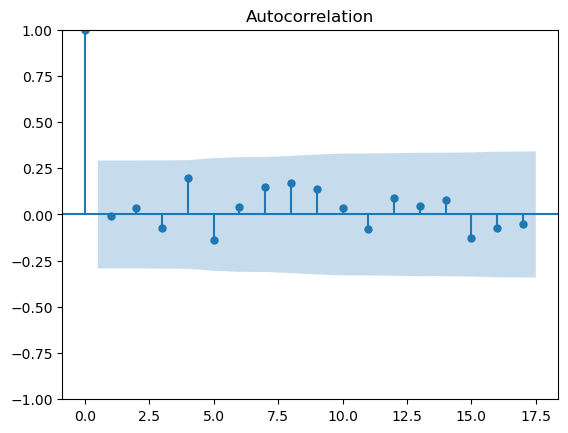

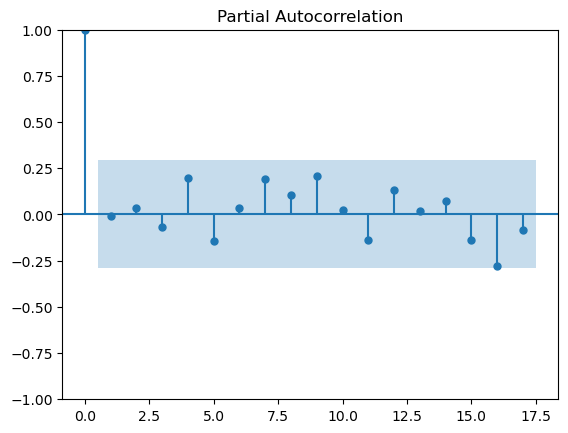

In [390]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(store_sales)
plot_pacf(store_sales)
plt.show()

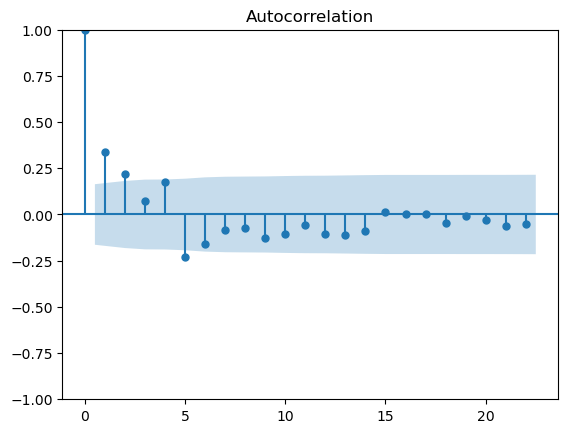

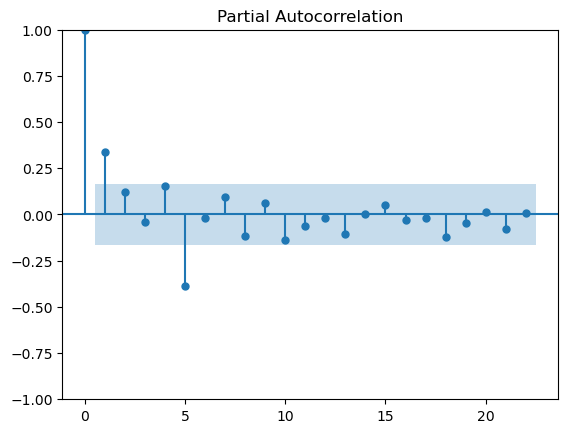

In [391]:
plot_acf(week_sales)
plot_pacf(week_sales)
plt.show()

In [392]:
from datetime import datetime, timedelta
train_end = datetime(2011,10,14)
test_end = datetime(2012,10,26)

In [393]:
train_data = week_sales[:train_end]
test_data = week_sales[train_end+timedelta(days=1):test_end]

In [394]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]

In [395]:
from statsmodels.tsa.arima.model import ARIMA

In [396]:
model = ARIMA(train_data, order=(2,0,2))

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [397]:
model_fit = model.fit()

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [398]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           Weekly_Sales   No. Observations:                   89
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1491.309
Date:                Tue, 03 Feb 2026   AIC                           2994.618
Time:                        18:55:08   BIC                           3009.550
Sample:                    02-05-2010   HQIC                          3000.636
                         - 10-14-2011                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        4.66e+07   1.11e-08   4.21e+15      0.000    4.66e+07    4.66e+07
ar.L1         -1.0629      0.090    -11.801      0.000      -1.239      -0.886
ar.L2         -0.4826      0.081     -5.944      0.000      -0.642      -0.323
ma.L1          1.4792      0.084     17.683      0.000       1.315       1.643
ma.L2          0.9849      0.107      9.230      0.000       0.776       1.194
sigma2      2.175e+13   1.11e-14   1.97e+27      0.000    2.17e+13    2.17e+13
===================================================================================
Ljung-Box (L1) (Q):                   0.38   Jarque-Bera (JB):               458.82
Prob(Q):                              0.54   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             2.66
Prob(H) (two-sided):                  0.92   Kurtosis:                        12.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.2e+41. Standard errors may be unstable.
"""

In [399]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

2011-10-21 00:00:00
2012-10-26 00:00:00


In [400]:
pred = model_fit.predict(start=pred_start_date, end=pred_end_date)
residuals = test_data - pred

<Axes: ylabel='Density'>

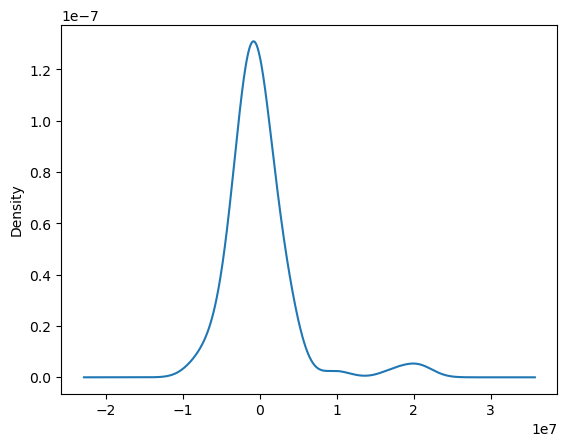

In [401]:
model_fit.resid.plot(kind='kde')

<Axes: xlabel='Date'>

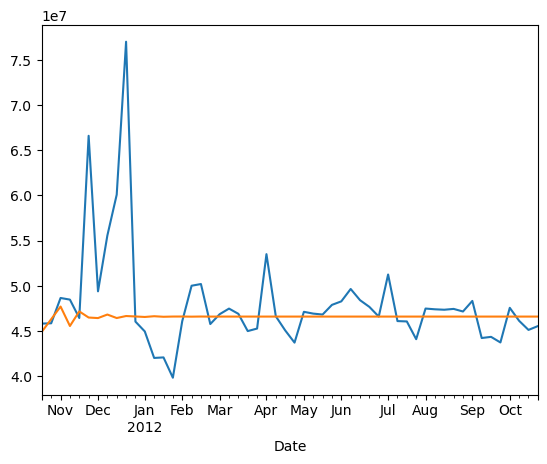

In [402]:
test_data.plot()
pred.plot()

### 4/2/26

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [260]:
df = pd.read_csv("F:/Financial Lab/sample1.txt", sep='\s+')
df.head()

,date,axp,vw,ew,sp
0,20010904,0.000824,-0.001658,-0.005708,-0.000565
1,20010905,0.007682,-0.003242,-0.008926,-0.001059
2,20010906,-0.039477,-0.020733,-0.014187,-0.022390
3,20010907,-0.019274,-0.017769,-0.011476,-0.018637
4,20010910,0.011850,0.003513,-0.007368,0.006226


In [261]:
df.isnull().sum()

date    0
axp     0
vw      0
ew      0
sp      0
dtype: int64

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2535 non-null   int64  
 1   axp     2535 non-null   float64
 2   vw      2535 non-null   float64
 3   ew      2535 non-null   float64
 4   sp      2535 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 99.2 KB


In [263]:
df['date'] = pd.to_datetime(df['date'], format="%Y%m%d")

In [264]:
df.set_index('date', inplace=True)

In [265]:
df.head()

,axp,vw,ew,sp
date,,,,
2001-09-04,0.000824,-0.001658,-0.005708,-0.000565
2001-09-05,0.007682,-0.003242,-0.008926,-0.001059
2001-09-06,-0.039477,-0.020733,-0.014187,-0.022390
2001-09-07,-0.019274,-0.017769,-0.011476,-0.018637
2001-09-10,0.011850,0.003513,-0.007368,0.006226


In [266]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2535 entries, 2001-09-04 to 2011-09-30
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   axp     2535 non-null   float64
 1   vw      2535 non-null   float64
 2   ew      2535 non-null   float64
 3   sp      2535 non-null   float64
dtypes: float64(4)
memory usage: 99.0 KB


In [267]:
df.index

DatetimeIndex(['2001-09-04', '2001-09-05', '2001-09-06', '2001-09-07',
               '2001-09-10', '2001-09-17', '2001-09-18', '2001-09-19',
               '2001-09-20', '2001-09-21',
               ...
               '2011-09-19', '2011-09-20', '2011-09-21', '2011-09-22',
               '2011-09-23', '2011-09-26', '2011-09-27', '2011-09-28',
               '2011-09-29', '2011-09-30'],
              dtype='datetime64[ns]', name='date', length=2535, freq=None)

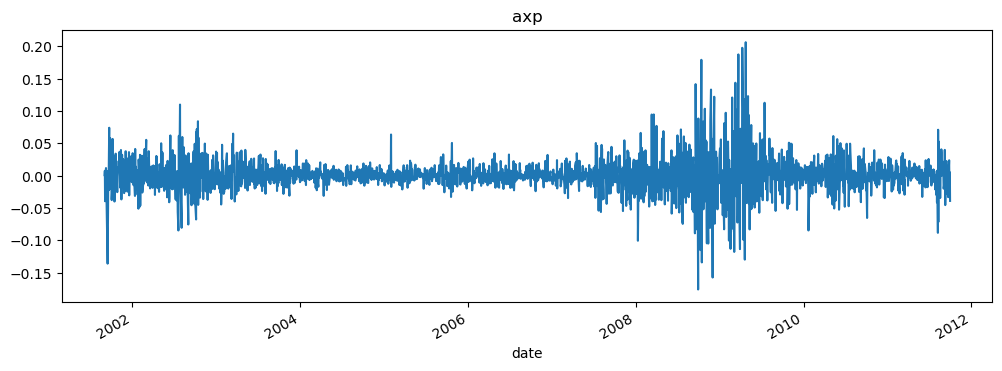

In [268]:
df['axp'].plot(figsize=(12,4))
plt.title('axp')
plt.show()

In [269]:
from statsmodels.tsa.stattools import adfuller

def adf_test(data):
    res = adfuller(data)
    print('ADF static: {}'.format(res[0]))
    print('p-value: {}'.format(res[1]))
    if res[1] <= 0.05:
        print('Reject null hypothesis -> Stationary')
    else:
        print('Not stationary')

In [270]:
adf_test(df['axp'])

ADF static: -8.592938692851861
p-value: 7.203914166030992e-14
Reject null hypothesis -> Stationary


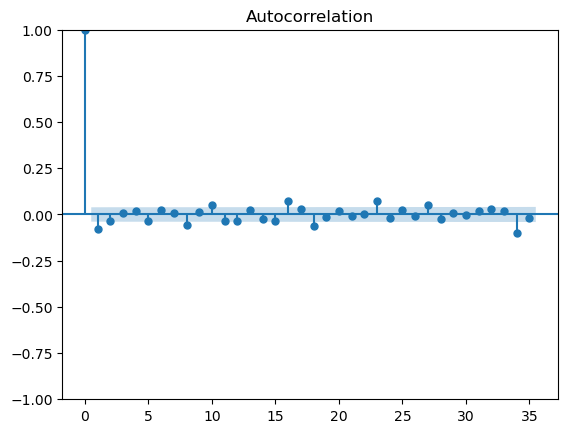

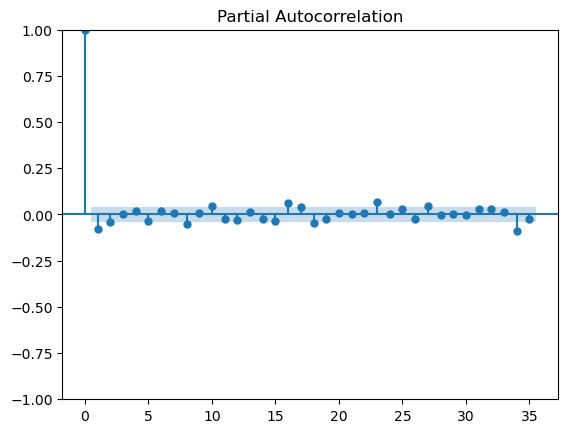

In [271]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['axp'])
plot_pacf(df['axp'])
plt.show()

In [272]:
from datetime import datetime, timedelta

train_end = datetime(2008,12,31)
test_end = datetime(2011,9,30)

In [273]:
train_data = df[:train_end]
test_data = df[train_end+timedelta(days=1):test_end]

In [274]:
train_data

,axp,vw,ew,sp
date,,,,
2001-09-04,0.000824,-0.001658,-0.005708,-0.000565
2001-09-05,0.007682,-0.003242,-0.008926,-0.001059
2001-09-06,-0.039477,-0.020733,-0.014187,-0.022390
2001-09-07,-0.019274,-0.017769,-0.011476,-0.018637
2001-09-10,0.011850,0.003513,-0.007368,0.006226
...,...,...,...,...
2008-12-24,0.000557,0.004509,0.005042,0.005781
2008-12-26,-0.003339,0.007194,0.011100,0.005356
2008-12-29,-0.011725,-0.004364,-0.015176,-0.003873


In [275]:
test_data

,axp,vw,ew,sp
date,,,,
2009-01-02,0.042049,0.030500,0.038274,0.031608
2009-01-05,0.032075,-0.000474,0.016764,-0.004668
2009-01-06,0.056140,0.011307,0.033647,0.007817
2009-01-07,-0.041766,-0.030452,-0.022271,-0.030010
2009-01-08,0.001499,0.006322,0.011896,0.003397
...,...,...,...,...
2011-09-26,0.023897,0.021588,0.009890,0.023336
2011-09-27,-0.010093,0.012842,0.015739,0.010688
2011-09-28,-0.012957,-0.023688,-0.025358,-0.020691


In [277]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]

In [278]:
from statsmodels.tsa.arima.model import ARIMA

ma = ARIMA(train_data['axp'], order=(15,0,12))

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [279]:
ma_fit = ma.fit()

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
F:\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [280]:
ma_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    axp   No. Observations:                 1842
Model:               ARIMA(15, 0, 12)   Log Likelihood                4309.909
Date:                Wed, 04 Feb 2026   AIC                          -8561.819
Time:                        13:16:08   BIC                          -8401.779
Sample:                             0   HQIC                         -8502.811
                               - 1842                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.464e-05      0.000      0.119      0.905      -0.001       0.001
ar.L1         -0.0496      0.436     -0.114      0.910      -0.905       0.806
ar.L2         -0.0530      0.441     -0.120      0.904      -0.918       0.812
ar.L3         -0.0026      0.440     -0.006      0.995      -0.866       0.860
ar.L4         -0.0279      0.453     -0.062      0.951      -0.916       0.860
ar.L5         -0.0285      0.365     -0.078      0.938      -0.744       0.687
ar.L6          0.0099      0.357      0.028      0.978      -0.690       0.710
ar.L7         -0.0156      0.223     -0.070      0.944      -0.453       0.422
ar.L8         -0.0074      0.250     -0.029      0.977      -0.498       0.483
ar.L9         -0.0388      0.244     -0.159      0.873      -0.516       0.439
ar.L10        -0.0207      0.220     -0.094      0.925      -0.451       0.410
ar.L11        -0.0443      0.189     -0.234      0.815      -0.415       0.327
ar.L12        -0.0947      0.195     -0.487      0.626      -0.476       0.287
ar.L13        -0.0421      0.063     -0.668      0.504      -0.165       0.081
ar.L14        -0.0248      0.063     -0.392      0.695      -0.149       0.099
ar.L15        -0.0619      0.060     -1.031      0.302      -0.179       0.056
ma.L1         -0.0003      0.437     -0.001      0.999      -0.858       0.857
ma.L2         -0.0315      0.446     -0.071      0.944      -0.906       0.843
ma.L3          0.0139      0.446      0.031      0.975      -0.860       0.888
ma.L4         -0.0228      0.458     -0.050      0.960      -0.920       0.875
ma.L5          0.0016      0.397      0.004      0.997      -0.776       0.779
ma.L6         -0.0186      0.387     -0.048      0.962      -0.777       0.740
ma.L7         -0.0425      0.225     -0.188      0.851      -0.484       0.400
ma.L8         -0.0080      0.255     -0.031      0.975      -0.507       0.491
ma.L9          0.0940      0.241      0.390      0.697      -0.379       0.567
ma.L10         0.0006      0.230      0.003      0.998      -0.450       0.451
ma.L11        -0.0329      0.214     -0.154      0.877      -0.452       0.386
ma.L12         0.1030      0.198      0.520      0.603      -0.285       0.491
sigma2         0.0005   9.59e-06     55.974      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              4664.82
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.66   Skew:                            -0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [281]:
print(pred_start_date)
print(pred_end_date)

2009-01-02 00:00:00
2011-09-30 00:00:00


In [282]:
pred = ma_fit.forecast(steps=len(test_data))
pred.index = test_data.index

F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
F:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [283]:
res = test_data - preds
res

,2009-01-02 00:00:00,2009-01-05 00:00:00,2009-01-06 00:00:00,2009-01-07 00:00:00,2009-01-08 00:00:00,2009-01-09 00:00:00,2009-01-12 00:00:00,2009-01-13 00:00:00,2009-01-14 00:00:00,2009-01-15 00:00:00,...,2011-09-23 00:00:00,2011-09-26 00:00:00,2011-09-27 00:00:00,2011-09-28 00:00:00,2011-09-29 00:00:00,2011-09-30 00:00:00,axp,ew,sp,vw
date,,,,,,,,,,,,,,,,,,,,,
2009-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [284]:
pred_start_date

Timestamp('2009-01-02 00:00:00')

In [285]:
pred_end_date

Timestamp('2011-09-30 00:00:00')

<Axes: ylabel='Density'>

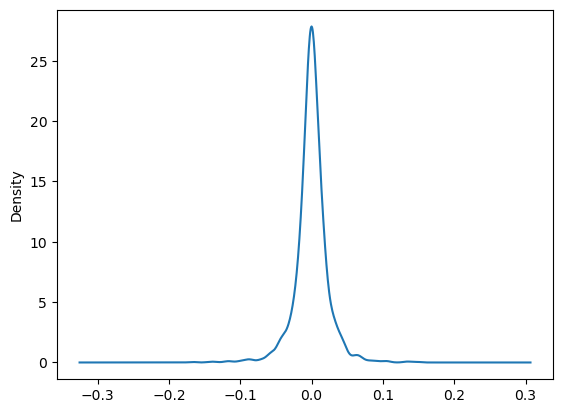

In [286]:
ma_fit.resid.plot(kind='kde')

In [287]:
test_data['Predicted_ARIMA'] = pred

C:\Users\hp\AppData\Local\Temp\ipykernel_24456\284031954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA'] = pred


<Axes: xlabel='date'>

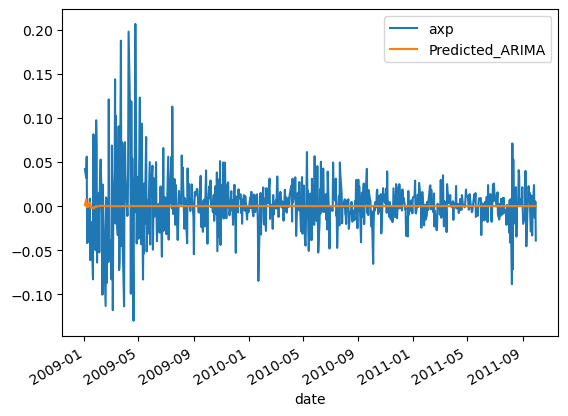

In [288]:
test_data[['axp','Predicted_ARIMA']].plot()